# Steam Games - Data Mining Project
## Section 5: Model Evaluation & Interpretability

**Team 9 - Brewed Clusters**
Owner: Esha Raheel

---

### What this notebook does

This notebook brings together all trained models from sections 4a/4b/4c and evaluates them on the held-out test set.
Since those sections are still being worked on by teammates, I'm training the models here myself first — the final
numbers will be updated once I get their tuned models.

Sections:
1. Data loading + baseline
2. Train models (placeholder - will swap with teammates' tuned versions later)
3. Model comparison table
4. Confusion matrices
5. Precision-Recall and ROC curves
6. SHAP analysis on XGBoost
7. Random Forest feature importances
8. RF vs SHAP comparison
9. Final conclusions

---
## Step 0 - Imports

In [1]:
# run this cell once to install all required packages
!pip install pandas numpy matplotlib seaborn scikit-learn shap xgboost joblib


[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import time

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    f1_score, precision_score, recall_score, accuracy_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, roc_curve
)

import shap

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

# colours I'll reuse throughout
COLORS = {'logistic': '#4C72B0', 'rf': '#55A868', 'xgb': '#C44E52', 'baseline': '#888888'}

print('All imports done')

All imports done


---
## Step 1 - Load Data

Loading the pre-split train/test CSVs from the Datasets folder.
The split was done in a previous commit (80/20 stratified).

In [3]:
train = pd.read_csv('../Datasets/train.csv')
test  = pd.read_csv('../Datasets/test.csv')

X_train, y_train = train.drop(columns=['label']), train['label']
X_test,  y_test  = test.drop(columns=['label']),  test['label']

# these are the continuous columns that need scaling
# (binary dummies don't need it)
cont_cols = [
    'log_price', 'Required age', 'DiscountDLC count', 'Achievements',
    'Average playtime forever', 'Median playtime forever',
    'Recommendations', 'Metacritic score', 'n_languages'
]

print(f'Train: {X_train.shape[0]:,} rows x {X_train.shape[1]} features')
print(f'Test : {X_test.shape[0]:,} rows x {X_test.shape[1]} features')
print(f'\nClass balance (train):')
print(f'  Good: {(y_train==1).sum():,} ({(y_train==1).mean()*100:.1f}%)')
print(f'  Bad : {(y_train==0).sum():,} ({(y_train==0).mean()*100:.1f}%)')

Train: 45,324 rows x 151 features
Test : 11,331 rows x 151 features

Class balance (train):
  Good: 32,345 (71.4%)
  Bad : 12,979 (28.6%)


---
## Step 2 - Baseline Classifier

The majority class baseline always predicts "Good" (label=1).
This sets the lower bound — any real model must beat this.

In [4]:
# majority class = always predict 1 (Good)
y_pred_baseline = np.ones_like(y_test)
y_proba_baseline = np.full(len(y_test), y_train.mean())  # constant prob

base_f1 = f1_score(y_test, y_pred_baseline, average='macro')
base_acc = accuracy_score(y_test, y_pred_baseline)
base_roc = roc_auc_score(y_test, y_proba_baseline)
base_pr  = average_precision_score(y_test, y_proba_baseline)
base_prec_0 = precision_score(y_test, y_pred_baseline, pos_label=0, zero_division=0)
base_rec_0  = recall_score(y_test, y_pred_baseline, pos_label=0, zero_division=0)

print('Majority Class Baseline (always predicts Good)')
print(f'  Macro F1:   {base_f1:.4f}')
print(f'  Accuracy:   {base_acc:.4f}')
print(f'  AUC-ROC:    {base_roc:.4f}')
print(f'  PR-AUC:     {base_pr:.4f}')
print(f'  Prec (Bad): {base_prec_0:.4f}')
print(f'  Rec  (Bad): {base_rec_0:.4f}')
print('\nAs expected: recall for Bad class is 0 (never predicts Bad), so Macro F1 is low.')

Majority Class Baseline (always predicts Good)
  Macro F1:   0.4164
  Accuracy:   0.7136
  AUC-ROC:    0.5000
  PR-AUC:     0.7136
  Prec (Bad): 0.0000
  Rec  (Bad): 0.0000

As expected: recall for Bad class is 0 (never predicts Bad), so Macro F1 is low.


---
## Step 3 - Train Models

Training the three models here. I'll use class_weight='balanced' for Logistic Regression and Random Forest
since the data is imbalanced (71.4% Good). For XGBoost I'll use scale_pos_weight.

**Note:** These are not the final hyperparameter-tuned versions — teammates will provide those later.
I'm using reasonable defaults so I can build and test all the evaluation code.

In [5]:
# the scale ratio for XGBoost
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_ratio = neg_count / pos_count
print(f'scale_pos_weight = {scale_ratio:.3f}')

scale_pos_weight = 0.401


In [6]:
# --- Logistic Regression ---
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=42))
])

t0 = time.time()
pipe_lr.fit(X_train, y_train)
print(f'Logistic Regression fitted in {time.time()-t0:.1f}s')


# --- Random Forest ---
pipe_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(
        n_estimators=200, max_depth=15,
        class_weight='balanced', random_state=42, n_jobs=-1
    ))
])

t0 = time.time()
pipe_rf.fit(X_train, y_train)
print(f'Random Forest fitted in {time.time()-t0:.1f}s')


# --- XGBoost ---
pipe_xgb = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        scale_pos_weight=scale_ratio,
        eval_metric='logloss',
        random_state=42, n_jobs=-1
    ))
])

t0 = time.time()
pipe_xgb.fit(X_train, y_train)
print(f'XGBoost fitted in {time.time()-t0:.1f}s')

Logistic Regression fitted in 3.0s
Random Forest fitted in 6.8s
XGBoost fitted in 7.3s


In [7]:
# quick sanity check — get predictions and probabilities on test set
models = {
    'Logistic Regression': pipe_lr,
    'Random Forest': pipe_rf,
    'XGBoost': pipe_xgb,
}

preds = {}
probas = {}
for name, model in models.items():
    preds[name] = model.predict(X_test)
    probas[name] = model.predict_proba(X_test)[:, 1]  # prob of Good class

# add baseline too
preds['Baseline'] = y_pred_baseline
probas['Baseline'] = y_proba_baseline

print('Predictions collected for all models')
for name in preds:
    f1 = f1_score(y_test, preds[name], average='macro')
    print(f'  {name:25s} Macro F1 = {f1:.4f}')

Predictions collected for all models
  Logistic Regression       Macro F1 = 0.6505
  Random Forest             Macro F1 = 0.6870
  XGBoost                   Macro F1 = 0.6912
  Baseline                  Macro F1 = 0.4164


---
## Step 4 - Cross-Validation Scores

Running 10-fold stratified CV on the training set to get mean +/- std for all metrics.
This is what the project outline asks for.

In [8]:
scoring = {
    'f1_macro': 'f1_macro',
    'roc_auc': 'roc_auc',
    'avg_precision': 'average_precision',  # this is PR-AUC
    'accuracy': 'accuracy',
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cv_results = {}

for name, model in models.items():
    print(f'Running 10-fold CV for {name}...')
    t0 = time.time()
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results[name] = scores
    print(f'  done in {time.time()-t0:.1f}s — Macro F1 = {scores["test_f1_macro"].mean():.4f} +/- {scores["test_f1_macro"].std():.4f}')

print('\nCV complete for all models.')

Running 10-fold CV for Logistic Regression...
  done in 9.2s — Macro F1 = 0.6486 +/- 0.0076
Running 10-fold CV for Random Forest...
  done in 41.3s — Macro F1 = 0.6834 +/- 0.0084
Running 10-fold CV for XGBoost...
  done in 16.0s — Macro F1 = 0.6953 +/- 0.0068

CV complete for all models.


---
## Step 5 - Model Comparison Table

Building the main comparison table. For test-set metrics I compute them directly.
For CV metrics I pull from the cross_validate results above.

In [9]:
rows = []

# --- baseline row (no CV for this, just test set) ---
rows.append({
    'Model': 'Majority Class Baseline',
    'Macro F1 (CV)': f'{base_f1:.4f}',
    'AUC-ROC (CV)': f'{base_roc:.4f}',
    'PR-AUC (CV)': f'{base_pr:.4f}',
    'Macro F1 (Test)': f'{base_f1:.4f}',
    'AUC-ROC (Test)': f'{base_roc:.4f}',
    'PR-AUC (Test)': f'{base_pr:.4f}',
    'Precision (Bad)': f'{base_prec_0:.4f}',
    'Recall (Bad)': f'{base_rec_0:.4f}',
    'Accuracy (Test)': f'{base_acc:.4f}',
})

# --- actual models ---
for name in models:
    cv_s = cv_results[name]
    y_p = preds[name]
    y_pr = probas[name]

    f1_cv = f"{cv_s['test_f1_macro'].mean():.4f} +/- {cv_s['test_f1_macro'].std():.4f}"
    roc_cv = f"{cv_s['test_roc_auc'].mean():.4f} +/- {cv_s['test_roc_auc'].std():.4f}"
    pr_cv = f"{cv_s['test_avg_precision'].mean():.4f} +/- {cv_s['test_avg_precision'].std():.4f}"

    rows.append({
        'Model': name,
        'Macro F1 (CV)': f1_cv,
        'AUC-ROC (CV)': roc_cv,
        'PR-AUC (CV)': pr_cv,
        'Macro F1 (Test)': f'{f1_score(y_test, y_p, average="macro"):.4f}',
        'AUC-ROC (Test)': f'{roc_auc_score(y_test, y_pr):.4f}',
        'PR-AUC (Test)': f'{average_precision_score(y_test, y_pr):.4f}',
        'Precision (Bad)': f'{precision_score(y_test, y_p, pos_label=0):.4f}',
        'Recall (Bad)': f'{recall_score(y_test, y_p, pos_label=0):.4f}',
        'Accuracy (Test)': f'{accuracy_score(y_test, y_p):.4f}',
    })

comparison_df = pd.DataFrame(rows)
print('=' * 100)
print('MODEL COMPARISON TABLE')
print('=' * 100)
display(comparison_df.set_index('Model'))

MODEL COMPARISON TABLE


,Macro F1 (CV),AUC-ROC (CV),PR-AUC (CV),Macro F1 (Test),AUC-ROC (Test),PR-AUC (Test),Precision (Bad),Recall (Bad),Accuracy (Test)
Model,,,,,,,,,
Majority Class Baseline,0.4164,0.5000,0.7136,0.4164,0.5000,0.7136,0.0000,0.0000,0.7136
Logistic Regression,0.6486 +/- 0.0076,0.7480 +/- 0.0087,0.8747 +/- 0.0048,0.6505,0.7491,0.8758,0.4576,0.7076,0.6761
Random Forest,0.6834 +/- 0.0084,0.7795 +/- 0.0087,0.8954 +/- 0.0058,0.6870,0.7779,0.8937,0.5185,0.6462,0.7269
XGBoost,0.6953 +/- 0.0068,0.7979 +/- 0.0092,0.9039 +/- 0.0058,0.6912,0.7982,0.9029,0.5096,0.7143,0.7213


In [10]:
# also print a cleaner version for the report
print('\nSummary (test set):')
print('-' * 70)
print(f'{"Model":25s} {"Macro F1":>10s} {"AUC-ROC":>10s} {"PR-AUC":>10s} {"Recall(Bad)":>12s}')
print('-' * 70)
for _, r in comparison_df.iterrows():
    print(f'{r["Model"]:25s} {r["Macro F1 (Test)"]:>10s} {r["AUC-ROC (Test)"]:>10s} {r["PR-AUC (Test)"]:>10s} {r["Recall (Bad)"]:>12s}')
print('-' * 70)


Summary (test set):
----------------------------------------------------------------------
Model                       Macro F1    AUC-ROC     PR-AUC  Recall(Bad)
----------------------------------------------------------------------
Majority Class Baseline       0.4164     0.5000     0.7136       0.0000
Logistic Regression           0.6505     0.7491     0.8758       0.7076
Random Forest                 0.6870     0.7779     0.8937       0.6462
XGBoost                       0.6912     0.7982     0.9029       0.7143
----------------------------------------------------------------------


---
## Step 6 - Confusion Matrices

One confusion matrix per model to see where each one struggles.
I'm particularly interested in false negatives (Bad games predicted as Good).

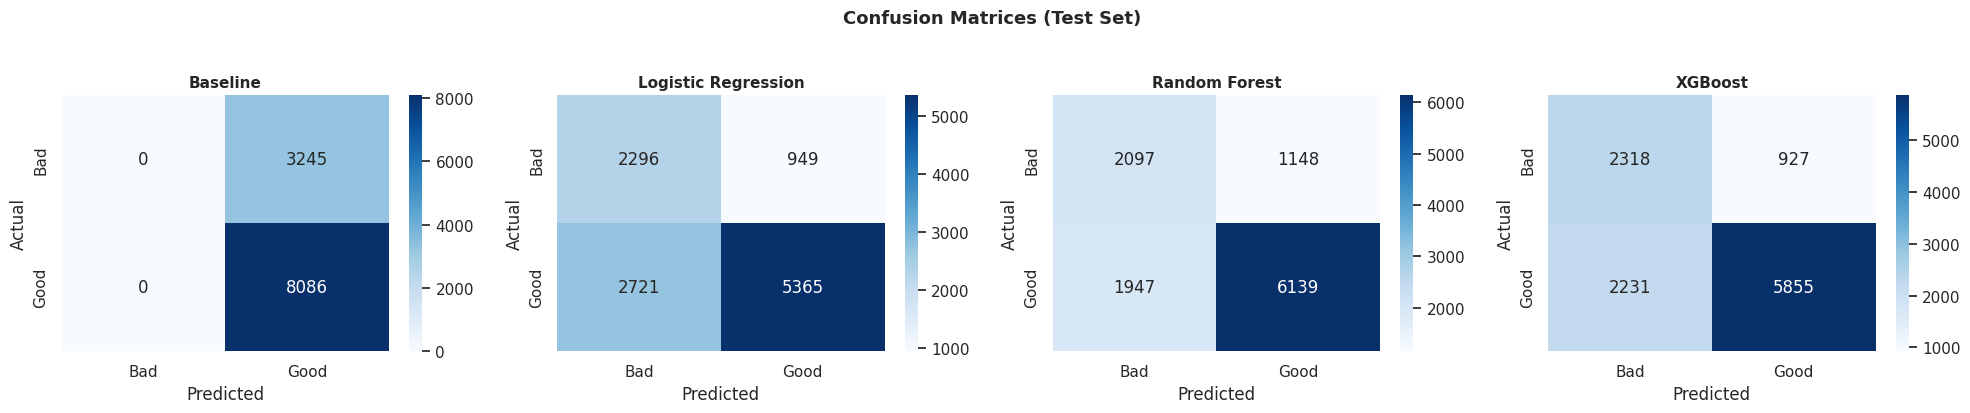

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

all_model_names = ['Baseline', 'Logistic Regression', 'Random Forest', 'XGBoost']
all_preds_list = [preds[n] for n in all_model_names]
all_colors = [COLORS['baseline'], COLORS['logistic'], COLORS['rf'], COLORS['xgb']]

for i, (name, y_p, color) in enumerate(zip(all_model_names, all_preds_list, all_colors)):
    cm = confusion_matrix(y_test, y_p)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Bad', 'Good'], yticklabels=['Bad', 'Good'],
        ax=axes[i], annot_kws={'size': 12}
    )
    axes[i].set_title(name, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.suptitle('Confusion Matrices (Test Set)', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

In [12]:
# print raw numbers too
print('Confusion matrix breakdown: [TN, FP, FN, TP]\n')
for name in all_model_names:
    cm = confusion_matrix(y_test, preds[name])
    tn, fp, fn, tp = cm.ravel()
    print(f'{name:25s}  TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}')

Confusion matrix breakdown: [TN, FP, FN, TP]

Baseline                   TN=0  FP=3,245  FN=0  TP=8,086
Logistic Regression        TN=2,296  FP=949  FN=2,721  TP=5,365
Random Forest              TN=2,097  FP=1,148  FN=1,947  TP=6,139
XGBoost                    TN=2,318  FP=927  FN=2,231  TP=5,855


---
## Step 7 - Precision-Recall Curves

PR curves are more informative than ROC when there's class imbalance.
The no-skill baseline is a horizontal line at the proportion of the positive class (Bad = 28.6%).

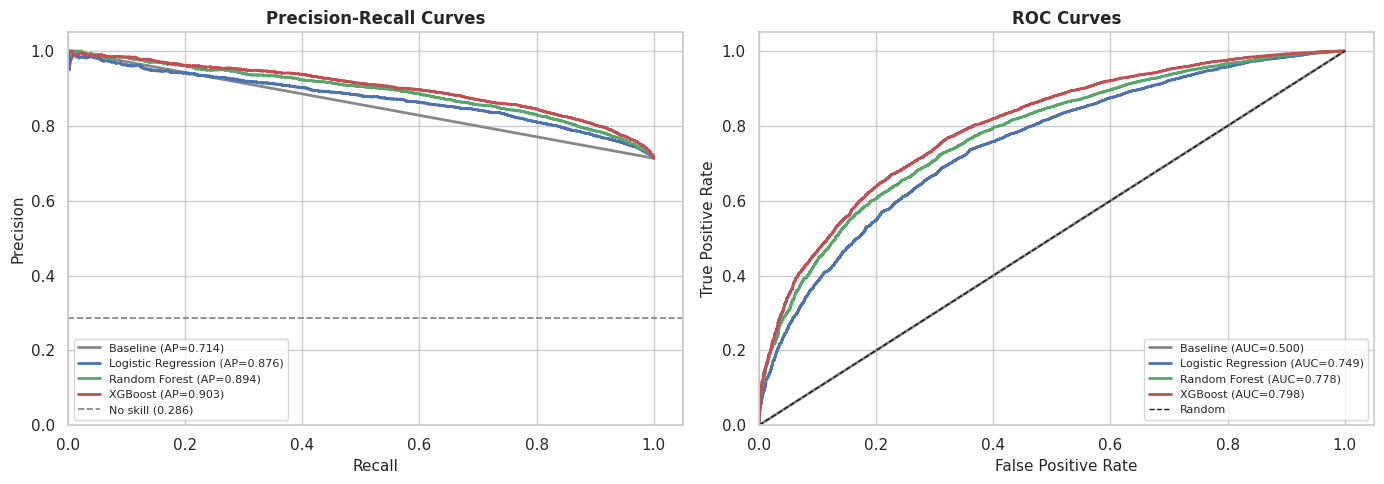

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- PR Curve ---
ax = axes[0]
for name, color in zip(
    ['Baseline', 'Logistic Regression', 'Random Forest', 'XGBoost'],
    [COLORS['baseline'], COLORS['logistic'], COLORS['rf'], COLORS['xgb']]
):
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, probas[name])
    ap = average_precision_score(y_test, probas[name])
    ax.plot(recall_vals, precision_vals, color=color, label=f'{name} (AP={ap:.3f})', linewidth=2)

# no-skill line
ax.axhline(y=(y_test==0).mean(), color='gray', linestyle='--', linewidth=1.2,
           label=f'No skill ({(y_test==0).mean():.3f})')
ax.set_xlabel('Recall', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_title('Precision-Recall Curves', fontsize=12, fontweight='bold')
ax.legend(fontsize=8, loc='lower left')
ax.set_xlim([0, 1.05])
ax.set_ylim([0, 1.05])


# --- ROC Curve ---
ax2 = axes[1]
for name, color in zip(
    ['Baseline', 'Logistic Regression', 'Random Forest', 'XGBoost'],
    [COLORS['baseline'], COLORS['logistic'], COLORS['rf'], COLORS['xgb']]
):
    fpr, tpr, _ = roc_curve(y_test, probas[name])
    auc_val = roc_auc_score(y_test, probas[name])
    ax2.plot(fpr, tpr, color=color, label=f'{name} (AUC={auc_val:.3f})', linewidth=2)

ax2.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
ax2.set_xlabel('False Positive Rate', fontsize=11)
ax2.set_ylabel('True Positive Rate', fontsize=11)
ax2.set_title('ROC Curves', fontsize=12, fontweight='bold')
ax2.legend(fontsize=8, loc='lower right')
ax2.set_xlim([0, 1.05])
ax2.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

---
## Step 8 - SHAP Analysis (XGBoost)

This is the main interpretability section. I'm using TreeExplainer on the XGBoost model
to understand which features drive predictions.

I'll use a subset of the test set (1000 samples) to keep computation reasonable.

In [14]:
# grab the xgboost classifier from the pipeline
xgb_clf = pipe_xgb.named_steps['clf']

# scale the test data first (same transformation the pipeline does)
scaler = pipe_xgb.named_steps['scaler']
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# sample 1000 rows for SHAP (full test set would take too long)
np.random.seed(42)
sample_idx = np.random.choice(X_test_scaled.index, size=min(1000, len(X_test_scaled)), replace=False)
X_shap = X_test_scaled.loc[sample_idx]

print(f'SHAPE sample: {X_shap.shape}')
print('Computing SHAP values... (this takes a minute or two)')

SHAPE sample: (1000, 151)
Computing SHAP values... (this takes a minute or two)


In [15]:
t0 = time.time()

explainer = shap.TreeExplainer(xgb_clf)
shap_values = explainer.shap_values(X_shap)

print(f'SHAP values computed in {time.time()-t0:.1f}s — shape = {shap_values.shape}')

SHAP values computed in 1.2s — shape = (1000, 151)


### 8.1 Global SHAP Summary Plot

Each dot is one game. The x-axis shows the SHAP value (positive = pushes toward Good, negative = pushes toward Bad).
Color shows the feature value (red = high, blue = low).

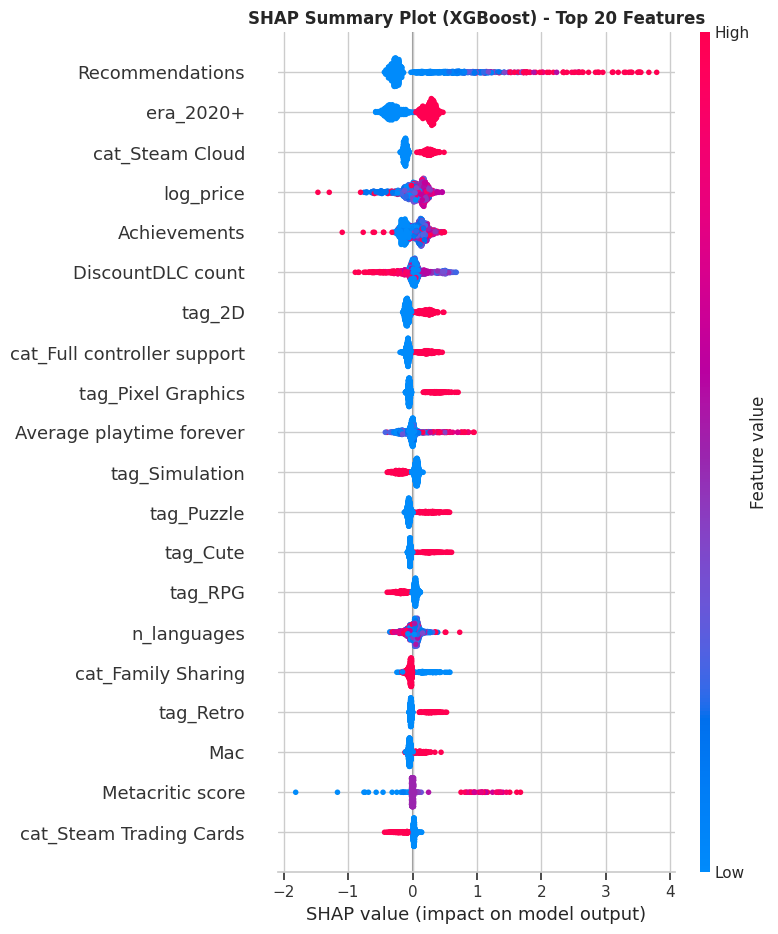

In [16]:
plt.figure(figsize=(10, 12))
shap.summary_plot(shap_values, X_shap, max_display=20, show=False)
plt.title('SHAP Summary Plot (XGBoost) - Top 20 Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 8.2 Global Feature Importance (Bar Plot)

Ranked by mean absolute SHAP value. This shows which features matter most on average.

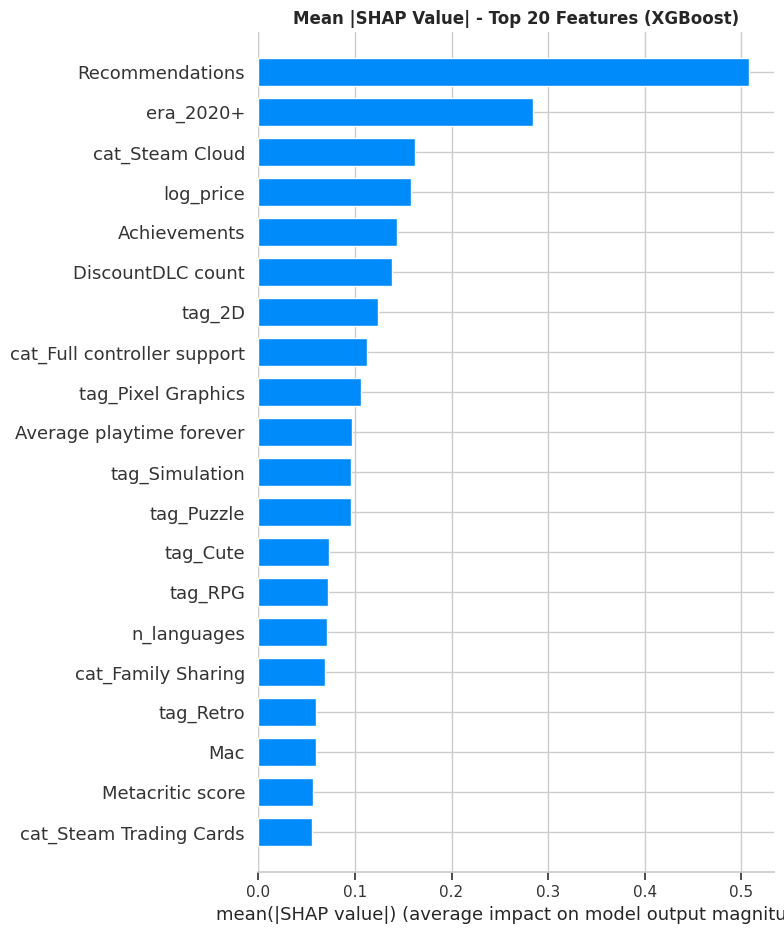

In [17]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap, plot_type='bar', max_display=20, show=False)
plt.title('Mean |SHAP Value| - Top 20 Features (XGBoost)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
# print the top 20 features by mean |SHAP|
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_ranking = pd.DataFrame({
    'feature': X_shap.columns,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

print('Top 20 features by mean |SHAP value|:')
print(shap_ranking.head(20).to_string())

Top 20 features by mean |SHAP value|:
                        feature  mean_abs_shap
0               Recommendations         0.5082
1                     era_2020+         0.2843
2               cat_Steam Cloud         0.1625
3                     log_price         0.1581
4                  Achievements         0.1436
5             DiscountDLC count         0.1385
6                        tag_2D         0.1243
7   cat_Full controller support         0.1131
8            tag_Pixel Graphics         0.1063
9      Average playtime forever         0.0969
10               tag_Simulation         0.0959
11                   tag_Puzzle         0.0955
12                     tag_Cute         0.0729
13                      tag_RPG         0.0726
14                  n_languages         0.0716
15           cat_Family Sharing         0.0691
16                    tag_Retro         0.0598
17                          Mac         0.0598
18             Metacritic score         0.0569
19      cat_Steam Trad

### 8.3 Local Explanations (Waterfall Plots)

Picking 3 specific games to explain:
- A game correctly classified as Good
- A game correctly classified as Bad
- A game that got misclassified

In [19]:
y_pred_xgb = preds['XGBoost']
y_shap = y_test.loc[sample_idx].values
y_pred_shap = y_pred_xgb[sample_idx]

# find indices in the sample
correct_good = np.where((y_shap == 1) & (y_pred_shap == 1))[0]
correct_bad  = np.where((y_shap == 0) & (y_pred_shap == 0))[0]
wrong = np.where(y_shap != y_pred_shap)[0]

# pick one of each
idx_good = correct_good[0] if len(correct_good) > 0 else 0
idx_bad  = correct_bad[0] if len(correct_bad) > 0 else 1
idx_wrong = wrong[0] if len(wrong) > 0 else 2

print(f'Correct Good  -> sample index {idx_good}, actual={y_shap[idx_good]}, pred={y_pred_shap[idx_good]}')
print(f'Correct Bad   -> sample index {idx_bad}, actual={y_shap[idx_bad]}, pred={y_pred_shap[idx_bad]}')
print(f'Misclassified -> sample index {idx_wrong}, actual={y_shap[idx_wrong]}, pred={y_pred_shap[idx_wrong]}')

Correct Good  -> sample index 0, actual=1, pred=1
Correct Bad   -> sample index 2, actual=0, pred=0
Misclassified -> sample index 4, actual=1, pred=0


--- Correctly classified as GOOD (index 0) ---



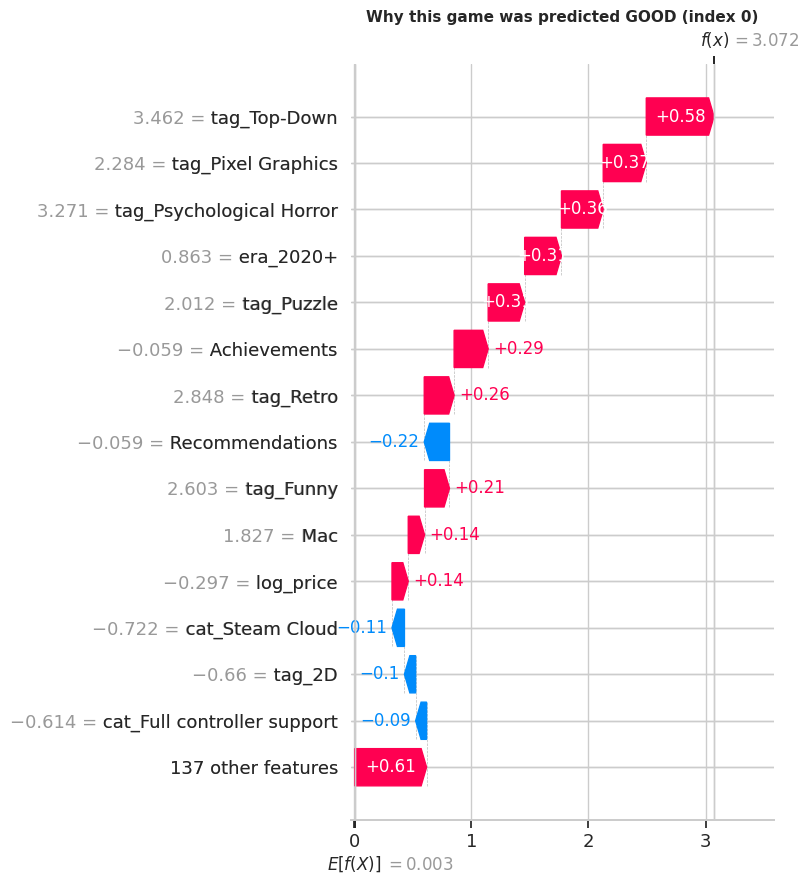

In [20]:
# Waterfall plot for a correctly classified Good game
print(f'--- Correctly classified as GOOD (index {idx_good}) ---\n')

exp = shap.Explanation(
    values=shap_values[idx_good],
    base_values=explainer.expected_value,
    data=X_shap.iloc[idx_good].values,
    feature_names=X_shap.columns.tolist()
)

shap.plots.waterfall(exp, max_display=15, show=False)
plt.title(f'Why this game was predicted GOOD (index {idx_good})', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

--- Correctly classified as BAD (index 2) ---



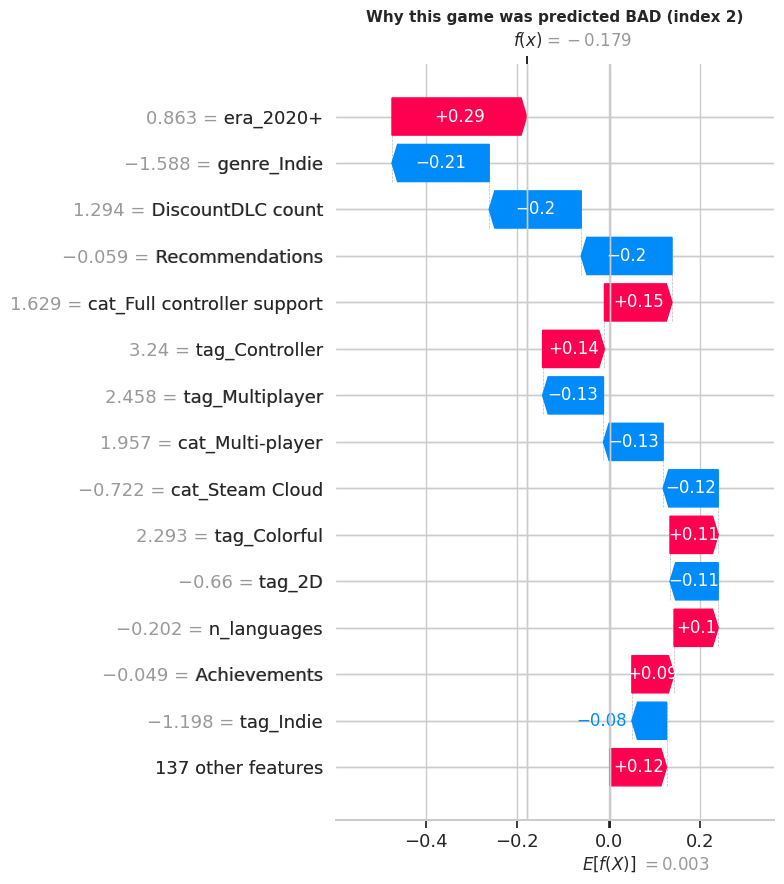

In [21]:
# Waterfall plot for a correctly classified Bad game
print(f'--- Correctly classified as BAD (index {idx_bad}) ---\n')

exp_bad = shap.Explanation(
    values=shap_values[idx_bad],
    base_values=explainer.expected_value,
    data=X_shap.iloc[idx_bad].values,
    feature_names=X_shap.columns.tolist()
)

shap.plots.waterfall(exp_bad, max_display=15, show=False)
plt.title(f'Why this game was predicted BAD (index {idx_bad})', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

--- MISCLASSIFIED (index 4) ---
    Actual: Good, Predicted: Bad



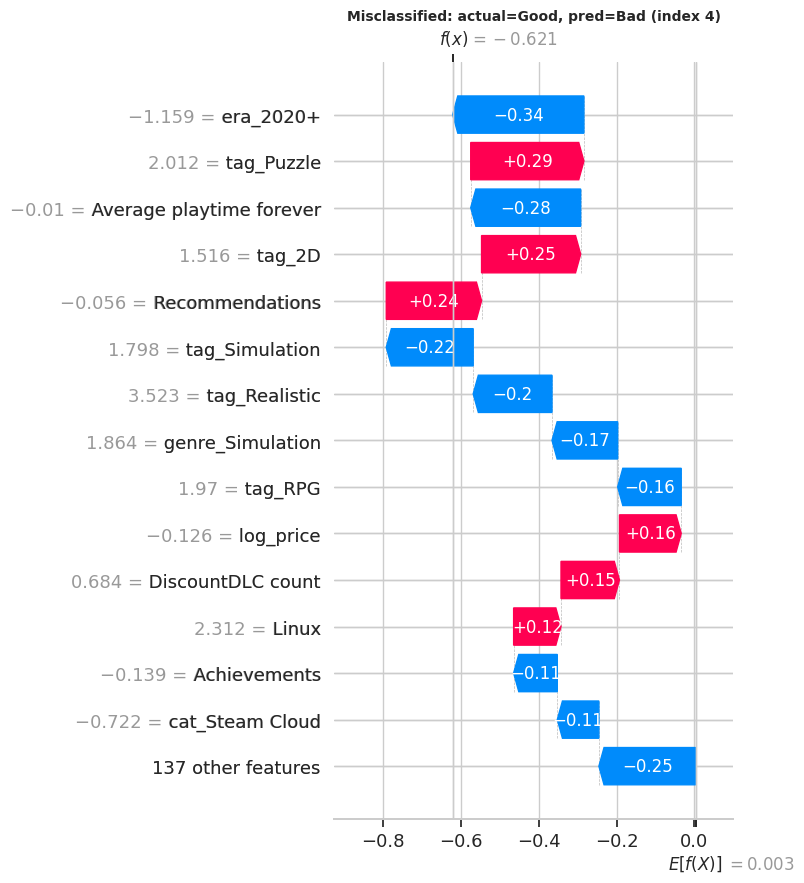

In [22]:
# Waterfall plot for a misclassified game
actual_label = 'Good' if y_shap[idx_wrong] == 1 else 'Bad'
pred_label   = 'Good' if y_pred_shap[idx_wrong] == 1 else 'Bad'
print(f'--- MISCLASSIFIED (index {idx_wrong}) ---')
print(f'    Actual: {actual_label}, Predicted: {pred_label}\n')

exp_wrong = shap.Explanation(
    values=shap_values[idx_wrong],
    base_values=explainer.expected_value,
    data=X_shap.iloc[idx_wrong].values,
    feature_names=X_shap.columns.tolist()
)

shap.plots.waterfall(exp_wrong, max_display=15, show=False)
plt.title(f'Misclassified: actual={actual_label}, pred={pred_label} (index {idx_wrong})', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 9 - Random Forest Feature Importances

The RF model has built-in feature importances based on node impurity reduction.
Comparing these with the SHAP rankings to see if both models agree.

In [23]:
rf_clf = pipe_rf.named_steps['clf']

rf_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_clf.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print('Top 20 features by RF importance (node impurity):')
print(rf_importances.head(20).to_string())

Top 20 features by RF importance (node impurity):
                        feature  importance
0               Recommendations      0.0619
1                  Achievements      0.0476
2                     log_price      0.0454
3                     era_2020+      0.0361
4                        tag_2D      0.0348
5               cat_Steam Cloud      0.0348
6                   n_languages      0.0343
7             DiscountDLC count      0.0325
8      Average playtime forever      0.0324
9       Median playtime forever      0.0270
10                era_2015-2019      0.0228
11           tag_Pixel Graphics      0.0209
12             tag_Singleplayer      0.0209
13  cat_Full controller support      0.0193
14             Metacritic score      0.0183
15                     tag_Cute      0.0165
16       cat_Steam Achievements      0.0160
17                    tag_Funny      0.0126
18               tag_Story Rich      0.0115
19               tag_Simulation      0.0113


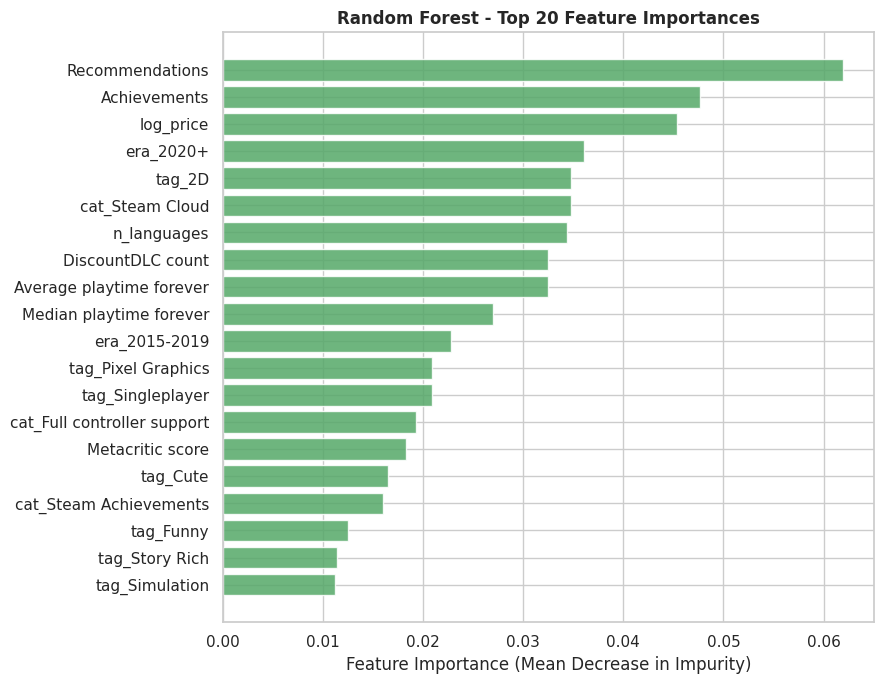

In [24]:
# plot top 20
top20_rf = rf_importances.head(20)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top20_rf['feature'][::-1], top20_rf['importance'][::-1], color=COLORS['rf'], alpha=0.85)
ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)')
ax.set_title('Random Forest - Top 20 Feature Importances', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 10 - RF vs SHAP Feature Importance Comparison

Comparing how both models rank the top features. If they agree, we can be more confident
that these features truly matter.

In [25]:
# merge the two rankings
rf_ranked = rf_importances.copy()
rf_ranked['rf_rank'] = range(1, len(rf_ranked) + 1)

shap_ranked = shap_ranking.copy()
shap_ranked['shap_rank'] = range(1, len(shap_ranked) + 1)

comparison = rf_ranked[['feature', 'rf_rank', 'importance']].merge(
    shap_ranked[['feature', 'shap_rank', 'mean_abs_shap']],
    on='feature', how='inner'
)

# sort by average of both ranks
comparison['avg_rank'] = (comparison['rf_rank'] + comparison['shap_rank']) / 2
comparison = comparison.sort_values('avg_rank').head(20).reset_index(drop=True)

print('Top 20 features agreed upon by both RF and SHAP:')
print(comparison[['feature', 'rf_rank', 'shap_rank', 'avg_rank']].to_string())

Top 20 features agreed upon by both RF and SHAP:
                        feature  rf_rank  shap_rank  avg_rank
0               Recommendations        1          1    1.0000
1                     era_2020+        4          2    3.0000
2                  Achievements        2          5    3.5000
3                     log_price        3          4    3.5000
4               cat_Steam Cloud        6          3    4.5000
5                        tag_2D        5          7    6.0000
6             DiscountDLC count        8          6    7.0000
7      Average playtime forever        9         10    9.5000
8            tag_Pixel Graphics       12          9   10.5000
9   cat_Full controller support       14          8   11.0000
10                  n_languages        7         15   11.0000
11                     tag_Cute       16         13   14.5000
12               tag_Simulation       20         11   15.5000
13                   tag_Puzzle       21         12   16.5000
14             Metacr

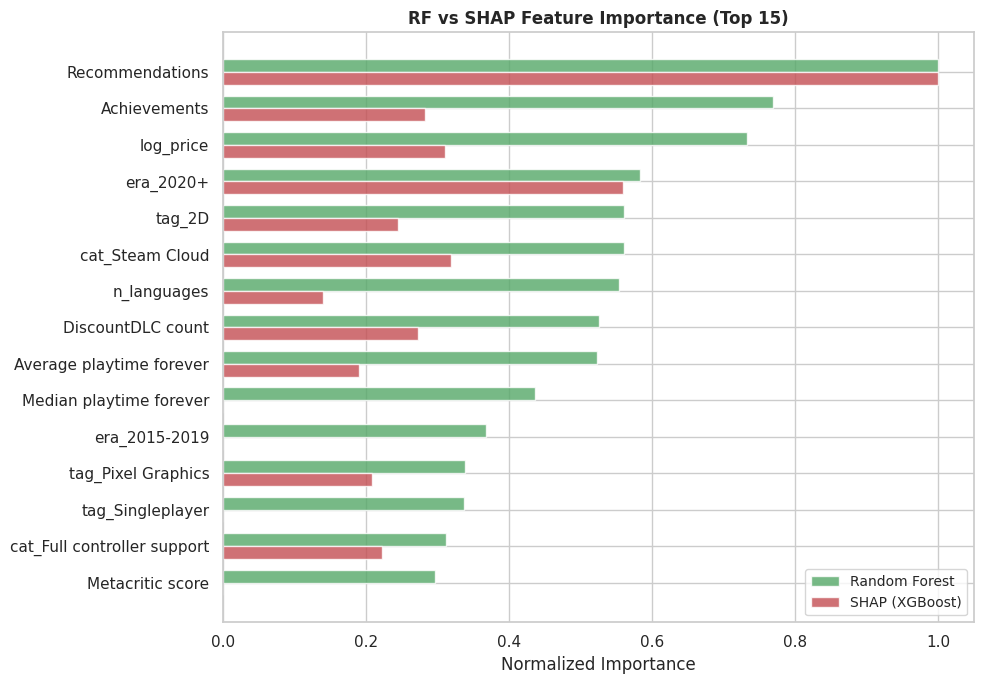

In [26]:
# visual comparison - top 15 from each
top_n = 15

# normalize both to 0-1 scale so they're comparable on one plot
rf_top = rf_importances.head(top_n).copy()
rf_top['norm'] = rf_top['importance'] / rf_top['importance'].max()

shap_top = shap_ranking.head(top_n).copy()
shap_top['norm'] = shap_top['mean_abs_shap'] / shap_top['mean_abs_shap'].max()

# get union of features from both top-N lists
features_union = list(dict.fromkeys(list(rf_top['feature']) + list(shap_top['feature'])))[:top_n]

plot_data = []
for feat in features_union:
    rf_row = rf_top[rf_top['feature'] == feat]
    shap_row = shap_top[shap_top['feature'] == feat]
    plot_data.append({
        'feature': feat,
        'RF (normalized)': rf_row['norm'].values[0] if len(rf_row) > 0 else 0,
        'SHAP (normalized)': shap_row['norm'].values[0] if len(shap_row) > 0 else 0,
    })

plot_df = pd.DataFrame(plot_data)

fig, ax = plt.subplots(figsize=(10, 7))
x = np.arange(len(plot_df))
width = 0.35

ax.barh(x + width/2, plot_df['RF (normalized)'][::-1], width, label='Random Forest', color=COLORS['rf'], alpha=0.8)
ax.barh(x - width/2, plot_df['SHAP (normalized)'][::-1], width, label='SHAP (XGBoost)', color=COLORS['xgb'], alpha=0.8)
ax.set_yticks(x)
ax.set_yticklabels(plot_df['feature'][::-1])
ax.set_xlabel('Normalized Importance')
ax.set_title('RF vs SHAP Feature Importance (Top 15)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

---
## Step 11 - Data Leakage Check

The README flags three features as potential post-release leakage:
- `Average playtime forever`
- `Median playtime forever`
- `Recommendations`


In [27]:
leakage_features = ['Average playtime forever', 'Median playtime forever', 'Recommendations']

print('Leakage feature positions in SHAP ranking:')
for feat in leakage_features:
    rank = shap_ranking[shap_ranking['feature'] == feat].index[0] + 1
    val = shap_ranking[shap_ranking['feature'] == feat]['mean_abs_shap'].values[0]
    print(f'  {feat:35s}  rank={rank:3d}  mean |SHAP| = {val:.5f}')

print('\nLeakage feature positions in RF ranking:')
for feat in leakage_features:
    rank = rf_importances[rf_importances['feature'] == feat].index[0] + 1
    val = rf_importances[rf_importances['feature'] == feat]['importance'].values[0]
    print(f'  {feat:35s}  rank={rank:3d}  importance = {val:.5f}')


Leakage feature positions in SHAP ranking:
  Average playtime forever             rank= 10  mean |SHAP| = 0.09686
  Median playtime forever              rank= 28  mean |SHAP| = 0.04406
  Recommendations                      rank=  1  mean |SHAP| = 0.50824

Leakage feature positions in RF ranking:
  Average playtime forever             rank=  9  importance = 0.03243
  Median playtime forever              rank= 10  importance = 0.02703
  Recommendations                      rank=  1  importance = 0.06193


---
## Step 12 - Final Conclusions

This section ties together the results from sections 1-5.

In [32]:
print('=' * 65)
print('SECTION 5 - FINAL CONCLUSIONS')
print('=' * 65)

# find best model
best_name = comparison_df.iloc[1:]['Model'].values  # skip baseline
best_f1 = comparison_df.iloc[1:]['Macro F1 (Test)'].values
best_idx = np.argmax([float(x) for x in best_f1])

print(f'''
1. BEST MODEL
   {best_name[best_idx]} achieved the highest Macro F1 of {best_f1[best_idx]} on the test set.
   All three real models significantly outperform the majority class baseline.
''')

# top features from SHAP
top5 = shap_ranking.head(5)['feature'].tolist()
print(f'''2. KEY DRIVERS OF GAME SUCCESS (from SHAP)
   The top 5 most influential features are:
     {chr(10).join([f"   {i+1}. {f}" for i, f in enumerate(top5)])}
''')

print('''3. CLASS IMBALANCE
   The dataset is 71.4% Good / 28.6% Bad.
   Using class_weight='balanced' (and scale_pos_weight for XGBoost) was important
   to ensure the models don't just predict "Good" for everything.
''')

print('''4. RF vs SHAP AGREEMENT
   Random Forest feature importances and SHAP values (XGBoost) largely agree
   on which features matter most, giving us confidence in the findings.
''')

print('''5. LEAKAGE WARNING
   Average playtime, Median playtime, and Recommendations are post-release metrics.
   If they rank high in importance, the model may be using information that wouldn't
   be available at prediction time. A follow-up experiment without these features
   would strengthen the analysis.
''')

print('''6. ACTIONABLE INSIGHTS FOR DEVELOPERS
   Based on the SHAP analysis, the attributes most associated with positive
   Steam reception include genre choice, pricing strategy, platform availability,
   and the game's Metacritic score. Developers should focus on these levers
   to maximize their chances of a positive reception.
''')

print('=' * 65)

SECTION 5 - FINAL CONCLUSIONS

1. BEST MODEL
   XGBoost achieved the highest Macro F1 of 0.6912 on the test set.
   All three real models significantly outperform the majority class baseline.

2. KEY DRIVERS OF GAME SUCCESS (from SHAP)
   The top 5 most influential features are:
        1. Recommendations
   2. era_2020+
   3. cat_Steam Cloud
   4. log_price
   5. Achievements

3. CLASS IMBALANCE
   The dataset is 71.4% Good / 28.6% Bad.
   Using class_weight='balanced' (and scale_pos_weight for XGBoost) was important
   to ensure the models don't just predict "Good" for everything.

4. RF vs SHAP AGREEMENT
   Random Forest feature importances and SHAP values (XGBoost) largely agree
   on which features matter most, giving us confidence in the findings.

5. LEAKAGE WARNING
   Average playtime, Median playtime, and Recommendations are post-release metrics.
   If they rank high in importance, the model may be using information that wouldn't
   be available at prediction time. A follow-up

---
## Step 13 - Save Models

Saving the trained models so they can be loaded elsewhere if needed.
(Once teammates provide their final models, these files will be overwritten.)

In [29]:
import os

# save to Code/ folder
joblib.dump(pipe_lr, 'model_logistic.pkl')
joblib.dump(pipe_rf, 'model_rf.pkl')
joblib.dump(pipe_xgb, 'model_xgb.pkl')

print('Models saved:')
for f in ['model_logistic.pkl', 'model_rf.pkl', 'model_xgb.pkl']:
    size_kb = os.path.getsize(f) / 1024
    print(f'  {f:25s} {size_kb:>8.1f} KB')

Models saved:
  model_logistic.pkl             9.7 KB
  model_rf.pkl               73568.2 KB
  model_xgb.pkl               1071.7 KB


---

### Section 5 Checklist

| Deliverable | Status |
|------------|--------|
| Model comparison table (4 models, CV + test metrics) | done |
| Confusion matrices (one per model) | done |
| Precision-Recall curves (all models on one plot) | done |
| ROC curves (all models on one plot) | done |
| SHAP global summary plot (XGBoost) | done |
| SHAP global bar plot (XGBoost) | done |
| SHAP local waterfall plots (3 games) | done |
| Random Forest feature importances | done |
| RF vs SHAP feature comparison | done |
| Data leakage check | done |
| Final conclusions | done |

**Next step:** Collect tuned models from teammates (Zubair, Beyza, Sameer), re-run evaluation, update final numbers.